# 实验一：PyTorch 基础与线性模型

欢迎来到第一章实验课。在本实验中，你将学习利用 PyTorch 实现基础的线性回归与线性分类模型，并接触经验风险最小化（ERM）与结构风险最小化（SRM）的概念。

请按照提示在含有 `### START CODE HERE ###` 与 `### END CODE HERE ###` 之间的区域补充代码。不要修改区域之外的代码。

## 1. 线性回归模型

在本部分，我们首先生成一组符合 $y = 2X + 3 + noise$ 的随机数据，然后要求你使用 PyTorch 构建一个单输入单输出的线性网络来拟合这组数据。

### (a) 期望风险最小化（经验风险最小化 ERM）
通常使用均方误差（MSE Loss）作为损失函数。在这个步骤中，请完成模型定义、损失函数与优化器的实例化，并在训练循环中实现前向传播与反向传播。


## 前向传播与反向传播

在下面的线性回归、带正则化回归、Logistic 回归、SVM 甚至后面的 Softmax 分类中，你会反复写到同一套 PyTorch 基本流程。真正需要掌握的不是“背代码”，而是先想清楚下面几个问题：

. 你的输入 `X` 有几个特征？
. 你的模型要输出几个数？
. 你的任务是回归还是分类？
. 预测值和真实标签之间应该用什么损失函数比较？
. 一轮训练里，前向传播、清梯度、反向传播、参数更新的顺序是什么？

理解这些之后，`### START CODE HERE ###` 和 `### END CODE HERE ###` 之间的内容基本都能自己补出来。

### 1. 什么是线性层？

线性层可以理解为最简单的一层神经网络，它对输入做一次仿射变换：

$$\hat{y} = Wx + b$$

其中：

- $x$ 是输入特征
- $W$ 是可学习的权重
- $b$ 是可学习的偏置
- $\hat{y}$ 是模型输出

在 PyTorch 中，这种层通常由 `nn.Linear` 来实现。你不需要手动维护权重矩阵和偏置，PyTorch 会帮你创建参数，并把它们注册到模型里，后续优化器就可以自动更新这些参数。

所以，当题目要求你“定义一个线性模型”时，第一反应通常就是：这是不是一个 `nn.Linear` 问题？

### 2. 输入维度和输出维度怎么决定？

这是写线性层时最关键的判断。一个简单规则是：

- 输入维度 = 每个样本包含多少个特征
- 输出维度 = 你希望模型对每个样本输出多少个值

结合本实验的几个任务来看：

- 当前这道线性回归题里，`X` 的形状是 `(100, 1)`，说明一共有 100 个样本，每个样本只有 1 个输入特征，所以输入维度应当是 1。
- 目标 `y` 的形状也是 `(100, 1)`，说明每个样本只预测 1 个连续值，所以输出维度应当是 1。
- 后面的二分类数据 `X_cls` 形状是 `(100, 2)`，说明每个样本有 2 个特征，因此做 Logistic 回归或线性 SVM 时，输入维度应当是 2。
- 二分类若只输出一个“分数”或“logit”，输出维度通常是 1。
- 最后 MNIST 多分类中，一张图片会被展平成 `28*28` 维向量，而类别有 10 个，所以那里的输出维度应当对应 10 个类别。

也就是说，维度不是“猜”的，而是从数据张量的形状和任务目标直接读出来的。

### 3. `nn` 到底是什么意思？

`torch.nn` 里的 `nn` 是 neural network 的缩写，可以把它理解成“PyTorch 中和神经网络有关的工具箱”。这个工具箱里常见的内容有：

- 各种网络层，例如 `nn.Linear`、`nn.Conv2d`
- 各种损失函数，例如 `nn.MSELoss`、`nn.BCEWithLogitsLoss`、`nn.CrossEntropyLoss`
- 一些容器和模块基类，例如 `nn.Module`

在入门阶段，你可以先形成这样一个印象：

- “模型里的层”通常来自 `nn`
- “训练时比较预测值和标签的损失函数”也通常来自 `nn`

很多 `nn` 里的损失函数都不是直接拿来写公式，而是先“实例化”，再“像函数一样调用”。也就是说，你会先得到一个损失对象，然后把 `prediction` 和 `target` 传进去算损失值。

### 4. 什么是均方误差损失（MSE Loss）？

回归任务常用均方误差（Mean Squared Error, MSE）来衡量预测值和真实值之间的差距。它的基本思想是：

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

含义很直观：

- 先看预测值和真实值差了多少
- 再把误差平方，使正负误差都变成正数
- 最后对所有样本求平均

平方的作用是让“大误差”受到更重的惩罚，所以 MSE 很适合回归问题。

在 PyTorch 中，回归题如果题目没有特别说明，首先想到的损失函数通常就是 `nn.MSELoss`。

### 5. 前向传播到底做了什么？

前向传播（Forward Propagation）就是：把输入送进模型，得到输出。

如果你已经定义好了模型，那么在 PyTorch 里，通常直接把输入张量喂给模型对象即可触发前向传播。对于当前这道题，前向传播的结果应该是“模型对所有样本的预测值”。

你可以把它理解成：

- 输入：`X`
- 经过线性层：自动计算 $Wx+b$
- 输出：预测结果 `y_pred`

### 6. 反向传播到底做了什么？

反向传播（Backward Propagation）是在你已经算出损失之后，求出这个损失对模型参数的梯度。

核心思想是链式法则：

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W}$$

在 PyTorch 中，只要计算图是连起来的，你通常不需要手推每个偏导；调用损失张量的反向传播方法后，框架会自动把每个参数对应的梯度存到参数的 `.grad` 里。

### 7. 一次完整训练迭代的标准顺序

下面这套顺序是后面多个代码单元都会重复出现的核心模板：

1. 先用模型对输入做前向传播，得到预测值。
2. 用损失函数比较预测值和真实标签，得到一个标量损失。
3. 在反向传播前先把旧梯度清零。
4. 对当前损失做反向传播，计算梯度。
5. 调用优化器根据梯度更新参数。

这个顺序不能随意打乱，特别是“清梯度”这一步。因为 PyTorch 默认会把梯度累积起来，如果不清零，当前轮次的梯度会和上一轮混在一起。

### 8. 从定义模型到训练结束，中间经过了哪些 PyTorch 基本操作？

把当前线性回归题拆开看，整个过程其实就这几类操作：

1. 用 `torch` 创建和组织数据张量，例如这里的 `X` 与 `y`。
2. 用 `nn` 定义模型层。
3. 用 `nn` 选择合适的损失函数。
4. 用 `torch.optim` 选择优化器，并把模型参数交给它管理。
5. 在循环里重复执行：前向传播 -> 计算损失 -> 清梯度 -> 反向传播 -> 更新参数。
6. 读取损失数值（如 `loss.item()`）做记录和可视化。

所以你看到训练代码时，不要把它当成零散语句，而要把它看成一个固定流程。

### 9. 怎么把这些知识用到当前代码块里？

你现在要补的内容，本质上只是在完成下面这些判断：

- 模型是不是应该用线性层？
- 这个线性层的输入和输出维度分别是多少？
- 这是回归任务还是分类任务？
- 对应应该选哪种损失函数？
- 优化器应该接收谁的参数？
- 在训练循环里，前向、损失、清梯度、反向、更新，这几个动作分别对应哪一行？

如果你能独立回答这些问题，就已经能把当前这道题的空缺补出来。

### 10. 对后面几个代码单元的迁移提示

后面几段代码虽然任务不同，但思路几乎完全一致：

- 带正则化的回归：模型结构不变，主要变化在优化器的设置。
- Logistic 回归：仍然是线性层，但任务变成二分类，所以损失函数不再是 MSE。
- 感知机：不再依赖 PyTorch 自带优化器，而是手动根据误分类条件更新参数。
- 线性 SVM：仍然是线性模型，但损失改成合页损失。
- Softmax 多分类：输入维度和输出维度都变了，但“线性层 + 合适损失 + 标准训练循环”的模式仍然不变。

因此，建议你每做一道题都先写出三件事：

- 输入维度是多少
- 输出维度是多少
- 该任务对应的损失函数是什么

只要这三件事判断对了，后面的训练代码通常就是同一套 PyTorch 基本动作的重复。

All tests passed for ERM Linear Regression!


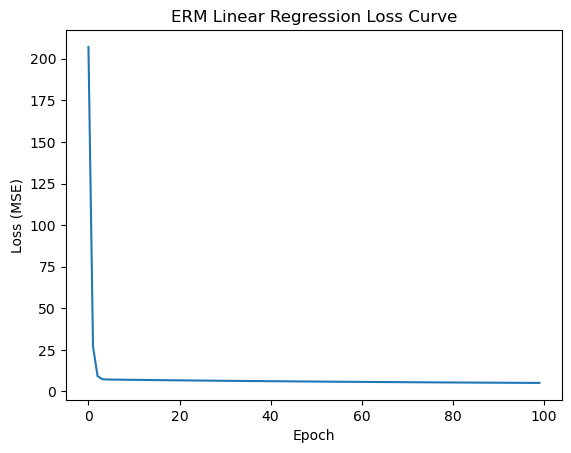

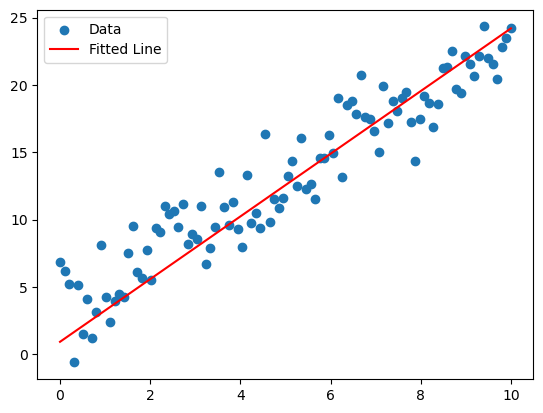

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 随机种子，固定以便复现
torch.manual_seed(42)

# 生成数据
X = torch.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 3 + torch.randn(X.shape) * 2

### START CODE HERE ###
# 1. 定义模型: 线性层 nn.Linear ，输入维度 1，输出维度 1

# 2. 损失函数: 均方误差损失 MSELoss

# 3. 优化器: SGD，传入 model_erm 的参数，学习率设为 0.01
### END CODE HERE ###

losses_erm = []
for epoch in range(100):
    ### START CODE HERE ###
    # 4. 前向传播：计算模型对 X 的预测值
    
    # 5. 计算损失 loss：将预测值 y_pred 和真实值 y 放入损失函数
    
    # 6. 梯度清零
    
    # 7. 反向传播
    
    # 8. 更新参数
    ### END CODE HERE ###
    
    losses_erm.append(loss.item())

# 简单的测试输出
assert len(losses_erm) == 100, "训练循环可能有误"
assert losses_erm[-1] < losses_erm[0], "损失值未出现下降"
print("All tests passed for ERM Linear Regression!")

# 绘制损失曲线
plt.plot(losses_erm)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('ERM Linear Regression Loss Curve')
plt.show()

# 绘制拟合直线
plt.scatter(X.numpy(), y.numpy(), label='Data')
plt.plot(X.numpy(), model_erm(X).detach().numpy(), color='red', label='Fitted Line')
plt.legend()
plt.show()

### (b) 结构风险最小化（SRM，即带正则化的回归）
为了防止过拟合，我们常在目标函数中加入表示模型复杂度的正则化项。常用的有 $L_2$ 正则化（Ridge 岭回归）。
在 PyTorch 中，我们可以直接在优化器（如 SGD、Adam 等）里设置 `weight_decay` 参数，这等价于对权重引入 $L_2$ 正则化。

All tests passed for SRM Linear Regression!


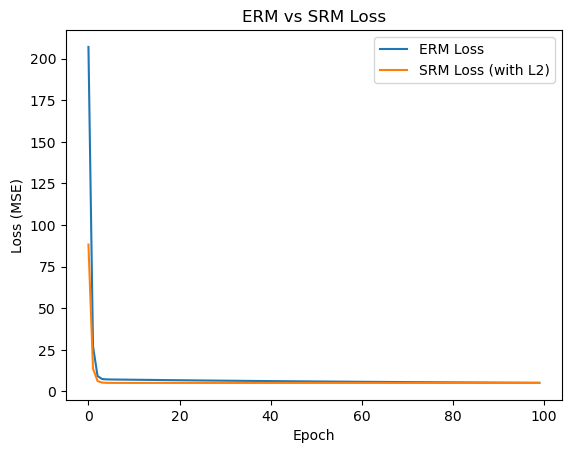

ERM weight: 2.326380729675293
SRM weight: 2.2546751499176025


In [2]:
# 重新初始化模型，保证对比基准一致
torch.manual_seed(42)
model_srm = nn.Linear(1, 1)

### START CODE HERE ###
# 1. 损失函数: MSELoss

# 2. 优化器: SGD，学习率为 0.01，并加入较大的 weight_decay（例如 weight_decay=1.5）观察差距。
### END CODE HERE ###

losses_srm = []
for epoch in range(100):
    ### START CODE HERE ###
    # 参考上一部分的实现，完成前向传播与反向传播
    
    ### END CODE HERE ###
    
    losses_srm.append(loss.item())

# 检查
assert len(losses_srm) == 100, "训练循环可能有误"
print("All tests passed for SRM Linear Regression!")

plt.plot(losses_erm, label='ERM Loss')
plt.plot(losses_srm, label='SRM Loss (with L2)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('ERM vs SRM Loss')
plt.legend()
plt.show()

# 观察两者学习后的权重差异（结构风险加上正则化后，权重一般更小）
print("ERM weight:", model_erm.weight.item())
print("SRM weight:", model_srm.weight.item())

## 2. 线性分类模型

在此部分，你将实现三种不同损失函数或思想的分类器：Logistic 回归、感知机（Perceptron）以及支持向量机（SVM）。

我们将首先生成一组简单的非线性可分（带有噪声的）二分类数据来测试这些分类模型。

### (a) Logistic 回归（逻辑回归）
使用 Cross Entropy 的变种（带有 Logits 的二分类交叉熵）作为目标函数，输出概率。
PyTorch 提供了 `BCEWithLogitsLoss()` 结合了 Sigmoid 并在数值上更稳定。

All tests passed for Logistic Regression!


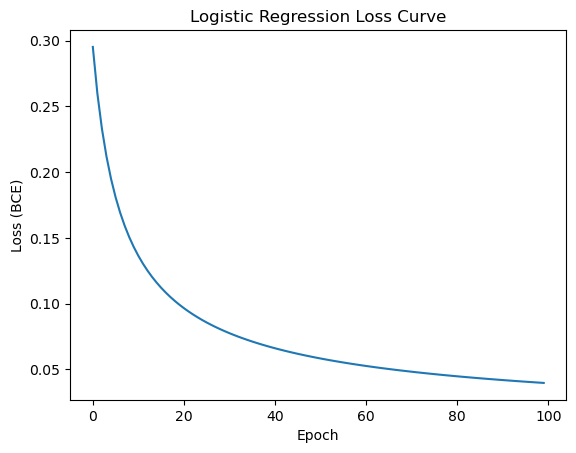

In [3]:
# 生成二分类数据
torch.manual_seed(10)
X_cls = torch.cat([torch.randn(50, 2) - 2, torch.randn(50, 2) + 2], dim=0)
y_cls = torch.cat([torch.zeros(50), torch.ones(50)]).reshape(-1, 1)

### START CODE HERE ###
# 1. 定义模型：输入两个特征，输出一个值

# 2. 损失函数: BCEWithLogitsLoss

# 3. 优化器: SGD，学习率设为 0.1
### END CODE HERE ###

losses_log = []
for epoch in range(100):
    ### START CODE HERE ###
    # 参考之前步骤，完成网络的前向传播和反向传播
    
    ### END CODE HERE ###
    
    losses_log.append(loss.item())

assert len(losses_log) == 100, "训练循环错误"
print("All tests passed for Logistic Regression!")

# 绘制损失曲线
plt.plot(losses_log)
plt.xlabel('Epoch')
plt.ylabel('Loss (BCE)')
plt.title('Logistic Regression Loss Curve')
plt.show()

### (b) 感知机（Perceptron）
感知机是最基础的线性分类算法。它的权重更新规则为：对于每个误分类的样本 $(x_i, y_i)$，更新 $w \leftarrow w + y_i \cdot x_i$ （这里我们将标签 $y$ 设置为 $\pm 1$）。

在下面的代码中，我们将展示如何抛开 PyTorch 自带的优化器，直接使用底层张量操作（Tensor Operations）在一小部分简单数据上手动实现感知机学习。

All tests passed for Perceptron!


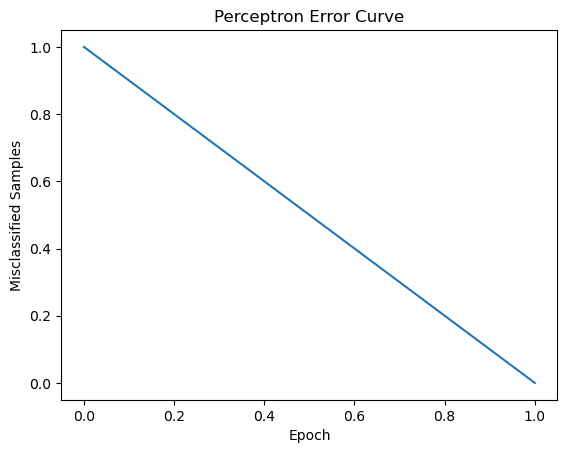

In [4]:
# 将标签转换为 \pm 1
y_perc = y_cls.clone()
y_perc[y_perc == 0] = -1

# 初始化权重 [w1, w2] 和偏置 b
w = torch.zeros(2)
b = torch.zeros(1)

lr = 0.1
epochs = 20

errors_list = []
for epoch in range(epochs):
    errors = 0
    for i in range(len(X_cls)):
        x_i = X_cls[i]
        label = y_perc[i]
        
        ### START CODE HERE ###
        # 1. 计算对数据的前向预测结果 activation ( 即 w \cdot x + b )
        # 提示: 可以使用 torch.dot 或者对 x_i 采用向量乘法
        
        # 2. 如果存在误分类（ 即 label * activation <= 0 ），进行参数更新
        ### END CODE HERE ###
        
    errors_list.append(errors)
    if errors == 0:
        break

assert w.shape == (2,), "权重 w 的形状错误"
print("All tests passed for Perceptron!")

plt.plot(errors_list)
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.title('Perceptron Error Curve')
plt.show()

### (c) 线性支持向量机（SVM）
线性 SVM 的目标是最大化间隔，可以通过最小化带有正则化项的合页损失（Hinge Loss）来实现。
$\text{Hinge Loss} = \max(0, 1 - y_i \cdot (\mathbf{w}^T x_i + b))$

我们可以在利用 PyTorch 自动求导机制的同时，手写这个合页损失。

All tests passed for SVM Regression!


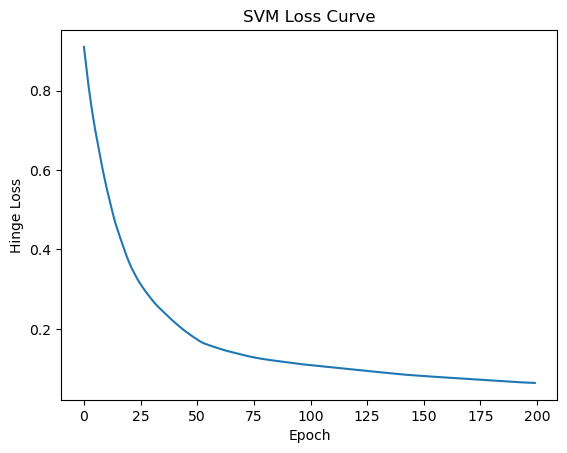

In [5]:
# 模型复用 nn.Linear(2, 1)
torch.manual_seed(99)
model_svm = nn.Linear(2, 1)

# 我们直接在 optimizer 中实现正则化部分来进行权重的约束
optimizer = torch.optim.SGD(model_svm.parameters(), lr=0.01, weight_decay=0.1)

svm_losses = []
for epoch in range(200):
    ### START CODE HERE ###
    # 1. 前向传播获取预测输出（不含非线性激活函数，直接获得边界相关的分数）
    
    # 2. 计算 Hinge Loss。提示: y_perc 标签需为 -1 和 1；使用 torch.clamp(..., min=0) 去取得最大值 \max(0, ...)
    # 算出的所有样本的损失需要使用 .mean() 取平均
    
    # 后退与更新
    ### END CODE HERE ###
    
    svm_losses.append(hinge_loss.item())

assert len(svm_losses) == 200, "训练循环错误"
print("All tests passed for SVM Regression!")

plt.plot(svm_losses)
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.title('SVM Loss Curve')
plt.show()

### 线性分类模型可视化

下面我们对三种线性分类器（Logistic 回归、感知机、SVM）的决策边界进行可视化，用不同颜色显示两类数据点，并绘制各模型的决策边界。

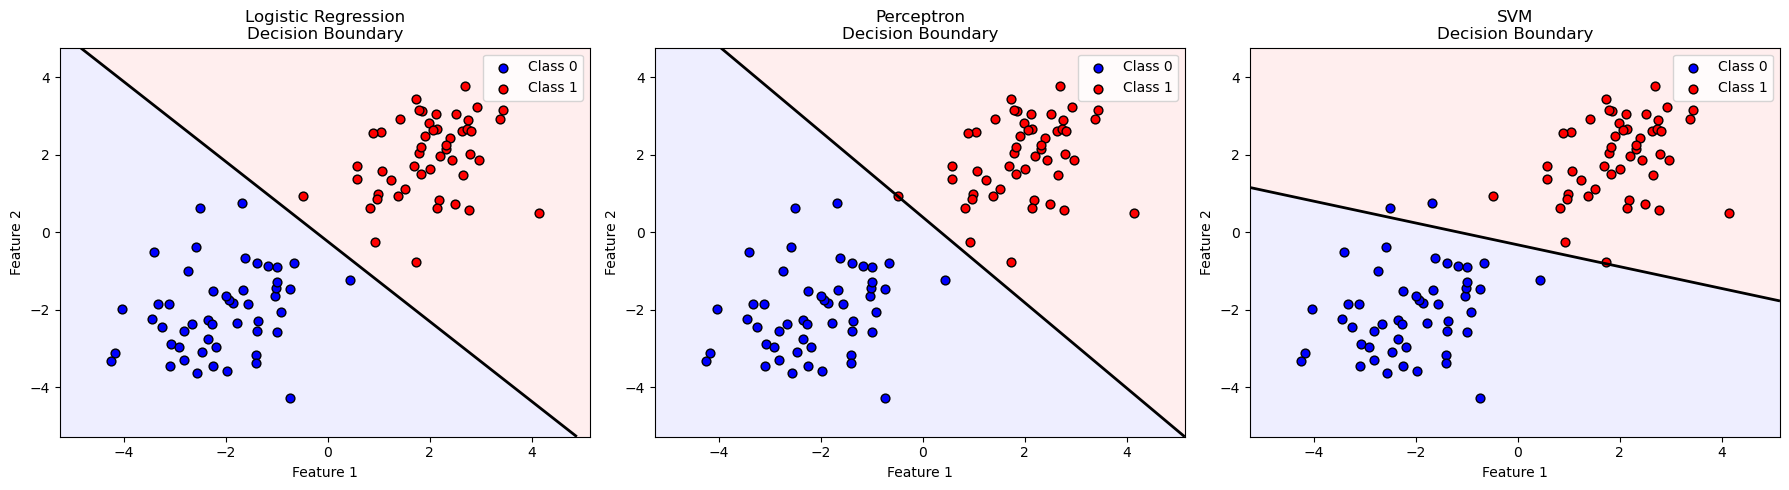

In [6]:
import numpy as np

def plot_decision_boundary(model_fn, X, y, title='Decision Boundary', ax=None):
    """绘制二分类决策边界与数据点"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    X_np = X.numpy()
    y_np = y.numpy().flatten()
    
    # 数据范围
    x_min, x_max = X_np[:, 0].min() - 1, X_np[:, 0].max() + 1
    y_min, y_max = X_np[:, 1].min() - 1, X_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    # 计算决策值
    with torch.no_grad():
        Z = model_fn(grid).numpy().reshape(xx.shape)

    # 绘制决策区域背景
    ax.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], alpha=0.2, colors=['#AAAAFF', '#FFAAAA'])
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

    # 用不同颜色绘制两类数据点
    ax.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1],
               c='blue', label='Class 0', edgecolors='k', s=40)
    ax.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1],
               c='red', label='Class 1', edgecolors='k', s=40)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic 回归决策边界
plot_decision_boundary(
    lambda x: model_log(x),
    X_cls, y_cls,
    title='Logistic Regression\nDecision Boundary',
    ax=axes[0]
)

# 感知机决策边界（使用手动权重 w, b）
def perceptron_fn(x):
    return (x @ w + b).unsqueeze(1)

# 将感知机标签 y_perc 转换回 0/1 以便可视化
y_perc_01 = ((y_perc + 1) / 2).clone()
plot_decision_boundary(
    perceptron_fn,
    X_cls, y_perc_01,
    title='Perceptron\nDecision Boundary',
    ax=axes[1]
)

# SVM 决策边界
plot_decision_boundary(
    lambda x: model_svm(x),
    X_cls, y_cls,
    title='SVM\nDecision Boundary',
    ax=axes[2]
)

plt.tight_layout()
plt.show()


## 3. 进阶：多分类线性模型 (Softmax Regression)

在理解了二分类之后，我们将逻辑回归扩展到处理多分类任务。常用的数据集比如 MNIST 数字识别（10 个类别），我们将使用单层的 `nn.Linear` 配合交叉熵损失 `CrossEntropyLoss` 进行处理。

（如果运行该部分代码时提示缺少依赖库，请按照《环境配置指南》进行安装。）

Epoch 1/10, Train Loss: 0.9835, Test Loss: 0.6003
Epoch 2/10, Train Loss: 0.5517, Test Loss: 0.4758
Epoch 3/10, Train Loss: 0.4719, Test Loss: 0.4250
Epoch 4/10, Train Loss: 0.4331, Test Loss: 0.3971
Epoch 5/10, Train Loss: 0.4089, Test Loss: 0.3783
Epoch 6/10, Train Loss: 0.3920, Test Loss: 0.3650
Epoch 7/10, Train Loss: 0.3794, Test Loss: 0.3540
Epoch 8/10, Train Loss: 0.3694, Test Loss: 0.3459
Epoch 9/10, Train Loss: 0.3614, Test Loss: 0.3396
Epoch 10/10, Train Loss: 0.3545, Test Loss: 0.3335


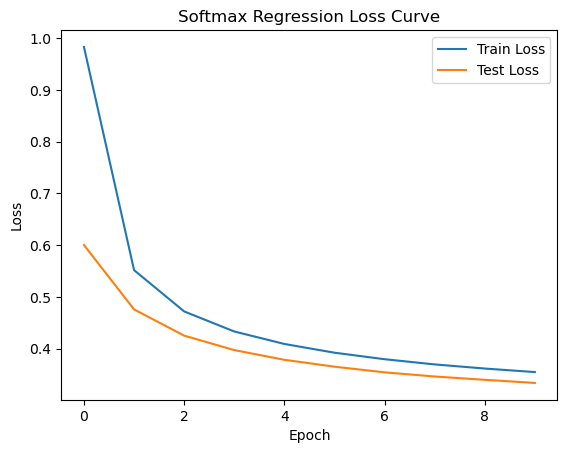

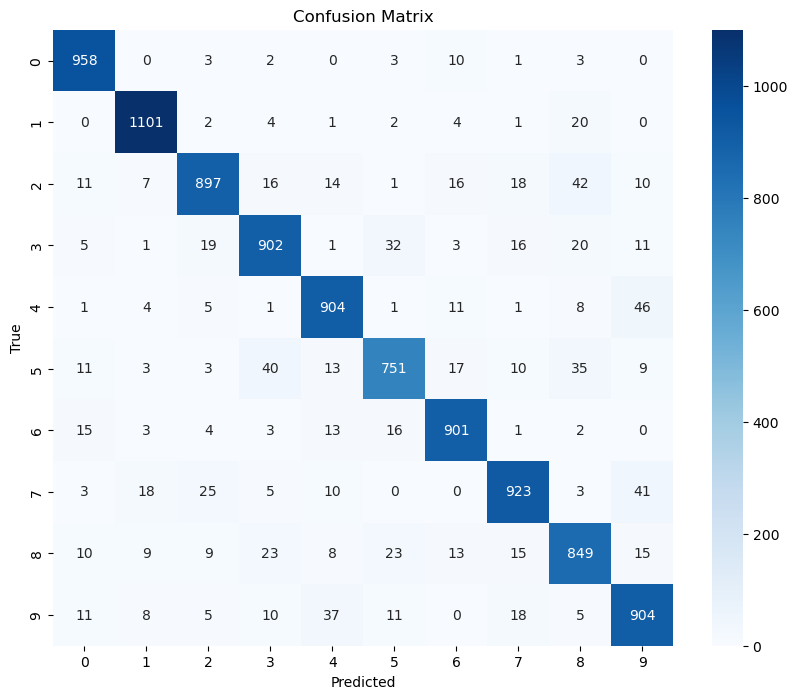

In [7]:
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 加载 MNIST 数据集
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

### START CODE HERE ###
# 定义模型: 输入单通道 28*28 的图像，由于需要将其展平，输入维度 28*28，输出由于是数字识别，维度为 10

# 定义交叉熵损失

# 定义优化器 SGD
### END CODE HERE ###

# 训练模型
train_losses = []
test_losses = []
for epoch in range(10):
    # 训练
    model_multi.train()
    batch_loss = 0
    for X, y in train_loader:
        ### START CODE HERE ###
        # 注意: 图像原始形状为 (batch_size, 1, 28, 28)，需要展平为 (batch_size, 28*28)
        
        # 前向与反向传播
        
        ### END CODE HERE ###
        batch_loss += loss.item()
    
    # 测试
    model_multi.eval()
    with torch.no_grad():
        test_loss = 0
        for X, y in test_loader:
            X = X.view(-1, 28 * 28)
            y_pred = model_multi(X)
            test_loss += criterion(y_pred, y).item()
        
    train_losses.append(batch_loss / len(train_loader))
    test_losses.append(test_loss / len(test_loader))
    print(f"Epoch {epoch+1}/10, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

# 绘制损失曲线
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Softmax Regression Loss Curve')
plt.legend()
plt.show()

# 绘制混淆矩阵
y_true = []
y_pred_list = []
with torch.no_grad():
    for X, y in test_loader:
        X = X.view(-1, 28 * 28)
        y_pred_list.extend(model_multi(X).argmax(dim=1).tolist())
        y_true.extend(y.tolist())

# 如果本地由于版本问题画不出热力图，可以不强求，这段主要用于可视化分析
cm = confusion_matrix(y_true, y_pred_list)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### 多分类模型可视化

下面我们从测试集中取一张图片，显示该图片及模型对其的预测结果（包括预测类别和各类别概率分布）。

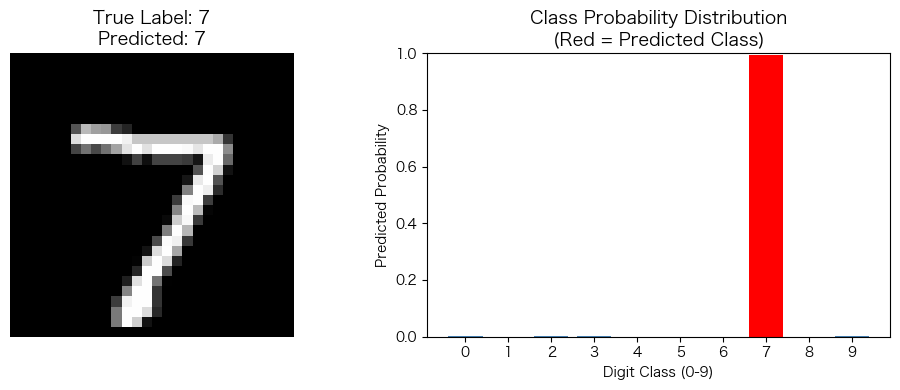

True Label: 7, Predicted: 7


In [13]:
import torch.nn.functional as F

# 从测试集取一个批次
test_iter = iter(test_loader)
sample_images, sample_labels = next(test_iter)

# 选取第一张图片
img = sample_images[0]           # shape: (1, 28, 28)
true_label = sample_labels[0].item()

# 模型预测
model_multi.eval()
with torch.no_grad():
    img_flat = img.view(1, -1)   # shape: (1, 784)
    logits = model_multi(img_flat)               # shape: (1, 10)
    probs = F.softmax(logits, dim=1).squeeze()   # shape: (10,)
    pred_label = logits.argmax(dim=1).item()

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Left: display image
axes[0].imshow(img.squeeze().numpy(), cmap='gray')
axes[0].set_title(f'True Label: {true_label}\nPredicted: {pred_label}', fontsize=13)
axes[0].axis('off')

# Right: bar chart of class probabilities
classes = list(range(10))
colors = ['red' if i == pred_label else 'steelblue' for i in classes]
axes[1].bar(classes, probs.numpy(), color=colors)
axes[1].set_xticks(classes)
axes[1].set_xlabel('Digit Class (0-9)')
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Class Probability Distribution\n(Red = Predicted Class)', fontsize=13)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
print(f'True Label: {true_label}, Predicted: {pred_label}')
